In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import optuna
optuna.logging.set_verbosity(optuna.logging.INFO)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.base import clone
from pympler.asizeof import asizeof

# Задание 1. "Формирование датасета"

In [4]:
def generate_dataset(n, m_half, random_state=None):
    # подбор случайного сида
    if random_state is not None:
        np.random.seed(random_state)
    
    # определение функций генерации столбцов разных типов
    binary_feature = lambda: np.random.choice([0, 1], size=n)
    nominal_feature = lambda: np.random.choice(['A', 'B', 'C', 'D'], size=n)
    ordinal_feature = lambda: np.random.choice([1, 2, 3, 4, 5], size=n)
    numeric_feature = lambda: np.random.uniform(0.0, 100.0, size=n)
    feature_generators = [binary_feature, nominal_feature, ordinal_feature, numeric_feature]
    
    data = {}
    columns = []
    
    # для каждого объекта создать m столбцов
    for state in [1, 2]:
        prefix = f'state{state}_'
        for i in range(m_half):
            col_name = prefix + f'feature{i+1}'
            data[col_name] = feature_generators[i % 4]()
            columns.append(col_name)
    
    # создание столбца коллизий (30% данных содержат положительные коллизии)
    data['collision'] = np.random.choice([0, 1], size=n, p=[0.7, 0.3])
    columns.append('collision')
    
    return pd.DataFrame(data, columns=columns)

In [5]:
# проверка функции
data = generate_dataset(100, 4)
data

,state1_feature1,state1_feature2,state1_feature3,state1_feature4,state2_feature1,state2_feature2,state2_feature3,state2_feature4,collision
0,0,D,4,60.783273,1,A,2,42.264316,0
1,0,A,3,86.880129,1,A,2,46.183305,1
2,0,B,1,50.657392,1,B,1,42.223743,0
3,1,D,1,0.655379,1,D,1,51.166394,0
4,0,C,2,47.230275,0,A,4,71.554961,1
...,...,...,...,...,...,...,...,...,...
95,0,A,4,7.532643,0,D,3,95.248160,0
96,1,B,5,45.910715,0,C,4,93.748330,0
97,0,D,2,18.756283,1,A,2,73.541150,0
98,0,C,1,6.789791,1,A,5,46.339167,0


In [6]:
# one-hot кодировка всех столбцов с текстовым типом данных
def one_hot_encode_all(data):
    categorical_columns = [col for col in data.columns if data[col].dtype == "O"]
    data = pd.get_dummies(data, columns=categorical_columns, dtype='int8')
    return data

In [7]:
# проверка one-hot кодировки
data = one_hot_encode_all(data)
data

,state1_feature1,state1_feature3,state1_feature4,state2_feature1,state2_feature3,state2_feature4,collision,state1_feature2_A,state1_feature2_B,state1_feature2_C,state1_feature2_D,state2_feature2_A,state2_feature2_B,state2_feature2_C,state2_feature2_D
0,0,4,60.783273,1,2,42.264316,0,0,0,0,1,1,0,0,0
1,0,3,86.880129,1,2,46.183305,1,1,0,0,0,1,0,0,0
2,0,1,50.657392,1,1,42.223743,0,0,1,0,0,0,1,0,0
3,1,1,0.655379,1,1,51.166394,0,0,0,0,1,0,0,0,1
4,0,2,47.230275,0,4,71.554961,1,0,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,4,7.532643,0,3,95.248160,0,1,0,0,0,0,0,0,1
96,1,5,45.910715,0,4,93.748330,0,0,1,0,0,0,0,1,0
97,0,2,18.756283,1,2,73.541150,0,0,0,0,1,1,0,0,0
98,0,1,6.789791,1,5,46.339167,0,0,0,1,0,1,0,0,0


In [8]:
# генерация 12 датасетов с разными комбинациями количества строк и признаков
dataframes = []

for n in [70, 250, 750, 1500]:
    for m in [2, 4, 6]:
        df = generate_dataset(n, m, 42)
        dataframes.append(one_hot_encode_all(df))

# Задание 2. "Выбор алгоритма"
Поскольку очевидно, что перед нами задача классификации (определение колизии), то и выбирались классические алгоритмы классификации:
- Логистическая регрессия (Logit)
- Метод опорных векторов (SVM)
- Метод k-ближайших соседей (KNN)
- Деревья решений (CART)

In [ ]:
# создание наиболее нагруженного датасета для проверки моделей
df = one_hot_encode_all(generate_dataset(n=5000, m_half=6, random_state=42))

X = df.drop('collision', axis=1)
y = df['collision']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
df.to_csv('train_df.csv')

С помощью фреймворка Optuna подбираются все гиперпарамеры для каждого из алгоритмов

In [10]:
def objective_logit(trial):
    solver = trial.suggest_categorical("solver", ["liblinear", "lbfgs", "saga"])

    if solver in ["liblinear", "saga"]:
        penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    else:
        penalty = "l2"

    C = trial.suggest_float("C", 1e-5, 1e5, log=True)
    fit_intercept = trial.suggest_categorical("fit_intercept", [True, False])
    intercept_scaling = trial.suggest_float("intercept_scaling", 1.0, 10.0) if fit_intercept else 1.0
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    model = LogisticRegression(
        penalty=penalty, C=C, solver=solver, max_iter=3000,
        fit_intercept=fit_intercept, intercept_scaling=intercept_scaling,
        class_weight=class_weight, random_state=42
    )

    score = cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy", n_jobs=-1).mean()
    return score

In [11]:
study_logit = optuna.create_study(direction='maximize')
study_logit.optimize(objective_logit, n_trials=100)
print(f"Best hyperparameters for Logistic Regression: {study_logit.best_params}")

[I 2025-03-15 09:41:55,707] A new study created in memory with name: no-name-8fd9c140-2fda-486e-b4eb-242e69155e75
[I 2025-03-15 09:42:00,269] Trial 0 finished with value: 0.6967500870719929 and parameters: {'solver': 'lbfgs', 'C': 5.565179891307081, 'fit_intercept': False, 'class_weight': None}. Best is trial 0 with value: 0.6967500870719929.
[I 2025-03-15 09:42:03,562] Trial 1 finished with value: 0.6967500870719929 and parameters: {'solver': 'lbfgs', 'C': 7.536524036462086, 'fit_intercept': True, 'intercept_scaling': 7.737638337959417, 'class_weight': None}. Best is trial 0 with value: 0.6967500870719929.
[I 2025-03-15 09:42:06,692] Trial 2 finished with value: 0.6967500870719929 and parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 0.017553680515153228, 'fit_intercept': False, 'class_weight': None}. Best is trial 0 with value: 0.6967500870719929.
[I 2025-03-15 09:42:07,576] Trial 3 finished with value: 0.49924812537467195 and parameters: {'solver': 'saga', 'penalty': 'l2', '

Best hyperparameters for Logistic Regression: {'solver': 'lbfgs', 'C': 5.565179891307081, 'fit_intercept': False, 'class_weight': None}


In [12]:
def objective_svc(trial):
    C = trial.suggest_float('C', 1e-3, 1e3, log=True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])
    degree = trial.suggest_int('degree', 1, 5) if kernel == 'poly' else 3
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    coef0 = trial.suggest_float('coef0', 0, 10) if kernel in ['poly', 'sigmoid'] else 0
    shrinking = trial.suggest_categorical('shrinking', [True, False])
    tol = trial.suggest_float('tol', 1e-5, 1e-1, log=True)
    cache_size = trial.suggest_int('cache_size', 50, 500)
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])

    model = SVC(
        C=C, kernel=kernel, degree=degree, gamma=gamma, coef0=coef0,
        shrinking=shrinking, probability=True, tol=tol, cache_size=cache_size,
        class_weight=class_weight, max_iter=3000, random_state=42
    )

    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()
    return score

In [13]:
study_svc = optuna.create_study(direction='maximize')
study_svc.optimize(objective_svc, n_trials=100)
print(f"Best hyperparameters for SVC: {study_svc.best_params}")

[I 2025-03-15 09:42:55,622] A new study created in memory with name: no-name-3058442e-bb89-42b2-9263-6c868f3cae12
[I 2025-03-15 09:42:57,753] Trial 0 finished with value: 0.6967500870719929 and parameters: {'C': 0.006957722395412812, 'kernel': 'linear', 'gamma': 'scale', 'shrinking': True, 'tol': 0.012683726373187848, 'cache_size': 265, 'class_weight': None}. Best is trial 0 with value: 0.6967500870719929.
[I 2025-03-15 09:43:03,604] Trial 1 finished with value: 0.6967500870719929 and parameters: {'C': 0.2324761170258493, 'kernel': 'rbf', 'gamma': 'auto', 'shrinking': True, 'tol': 0.0009412638694476082, 'cache_size': 222, 'class_weight': None}. Best is trial 0 with value: 0.6967500870719929.
[I 2025-03-15 09:43:09,205] Trial 2 finished with value: 0.5884994487002561 and parameters: {'C': 80.41186195738888, 'kernel': 'rbf', 'gamma': 'auto', 'shrinking': True, 'tol': 0.0009802631082099459, 'cache_size': 306, 'class_weight': None}. Best is trial 0 with value: 0.6967500870719929.
[I 2025-0

Best hyperparameters for SVC: {'C': 0.006957722395412812, 'kernel': 'linear', 'gamma': 'scale', 'shrinking': True, 'tol': 0.012683726373187848, 'cache_size': 265, 'class_weight': None}


In [14]:
def objective_knn(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 3, 20)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    algorithm = trial.suggest_categorical("algorithm", ["auto", "ball_tree", "kd_tree", "brute"])
    leaf_size = trial.suggest_int("leaf_size", 10, 50)
    p = trial.suggest_int("p", 1, 3)
    metric = trial.suggest_categorical("metric", ["minkowski", "euclidean", "manhattan", "chebyshev"])

    model = KNeighborsClassifier(
        n_neighbors=n_neighbors, weights=weights, algorithm=algorithm,
        leaf_size=leaf_size, p=p, metric=metric, n_jobs=-1
    )

    score = cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy", n_jobs=-1).mean()
    return score

In [15]:
study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=100)
print(f"Best hyperparameters for KNN: {study_knn.best_params}")

[I 2025-03-15 09:48:14,058] A new study created in memory with name: no-name-ca83572f-d399-4834-8fa5-c86c19d217e9
[I 2025-03-15 09:48:14,259] Trial 0 finished with value: 0.6792503973069729 and parameters: {'n_neighbors': 17, 'weights': 'distance', 'algorithm': 'ball_tree', 'leaf_size': 27, 'p': 1, 'metric': 'manhattan'}. Best is trial 0 with value: 0.6792503973069729.
[I 2025-03-15 09:48:14,448] Trial 1 finished with value: 0.655001081604734 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'algorithm': 'kd_tree', 'leaf_size': 11, 'p': 1, 'metric': 'manhattan'}. Best is trial 0 with value: 0.6792503973069729.
[I 2025-03-15 09:48:14,615] Trial 2 finished with value: 0.665499583291625 and parameters: {'n_neighbors': 14, 'weights': 'distance', 'algorithm': 'ball_tree', 'leaf_size': 24, 'p': 3, 'metric': 'chebyshev'}. Best is trial 0 with value: 0.6792503973069729.
[I 2025-03-15 09:48:14,831] Trial 3 finished with value: 0.6690013957762303 and parameters: {'n_neighbors': 6, 'weig

Best hyperparameters for KNN: {'n_neighbors': 20, 'weights': 'uniform', 'algorithm': 'auto', 'leaf_size': 50, 'p': 2, 'metric': 'minkowski'}


In [16]:
def objective_cart(trial):
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])
    splitter = trial.suggest_categorical("splitter", ["best", "random"])
    max_depth = trial.suggest_int("max_depth", 1, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.1)
    max_features = trial.suggest_categorical("max_features", [None, "sqrt", "log2"])
    max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 10, 100)
    min_impurity_decrease = trial.suggest_float("min_impurity_decrease", 0.0, 0.1)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])
    ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 0.1)

    model = DecisionTreeClassifier(
        criterion=criterion, splitter=splitter, max_depth=max_depth,
        min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
        min_weight_fraction_leaf=min_weight_fraction_leaf, max_features=max_features,
        max_leaf_nodes=max_leaf_nodes, min_impurity_decrease=min_impurity_decrease,
        class_weight=class_weight, ccp_alpha=ccp_alpha, random_state=42
    )

    score = cross_val_score(model, X_train, y_train, cv=3, scoring="accuracy", n_jobs=-1).mean()
    return score

In [17]:
study_cart = optuna.create_study(direction='maximize')
study_cart.optimize(objective_cart, n_trials=100)
print(f"Best hyperparameters for DecisionTree: {study_cart.best_params}")

[I 2025-03-15 09:48:49,583] A new study created in memory with name: no-name-09f3ed08-c801-4e71-8b83-9687bfe0dcc0
[I 2025-03-15 09:48:49,663] Trial 0 finished with value: 0.5658155543383597 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 7, 'min_samples_leaf': 4, 'min_weight_fraction_leaf': 0.09084939337432861, 'max_features': 'sqrt', 'max_leaf_nodes': 33, 'min_impurity_decrease': 0.04016815639444824, 'class_weight': 'balanced', 'ccp_alpha': 0.0747411616190399}. Best is trial 0 with value: 0.5658155543383597.
[I 2025-03-15 09:48:49,728] Trial 1 finished with value: 0.6967500870719929 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 14, 'min_samples_split': 7, 'min_samples_leaf': 9, 'min_weight_fraction_leaf': 0.08058917660642025, 'max_features': None, 'max_leaf_nodes': 83, 'min_impurity_decrease': 0.04740650391151835, 'class_weight': None, 'ccp_alpha': 0.03682700040880698}. Best is trial 1 with value: 0.69675008

Best hyperparameters for DecisionTree: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 14, 'min_samples_split': 7, 'min_samples_leaf': 9, 'min_weight_fraction_leaf': 0.08058917660642025, 'max_features': None, 'max_leaf_nodes': 83, 'min_impurity_decrease': 0.04740650391151835, 'class_weight': None, 'ccp_alpha': 0.03682700040880698}


In [18]:
# из подобраных гиперпараметров собираются экземпляры классов алгоритмов
models = {
    'Logit': LogisticRegression(**study_logit.best_params, max_iter=3000),
    'SVC': SVC(**study_svc.best_params),
    'KNN': KNeighborsClassifier(**study_knn.best_params),
    'CART': DecisionTreeClassifier(**study_cart.best_params)
}

70


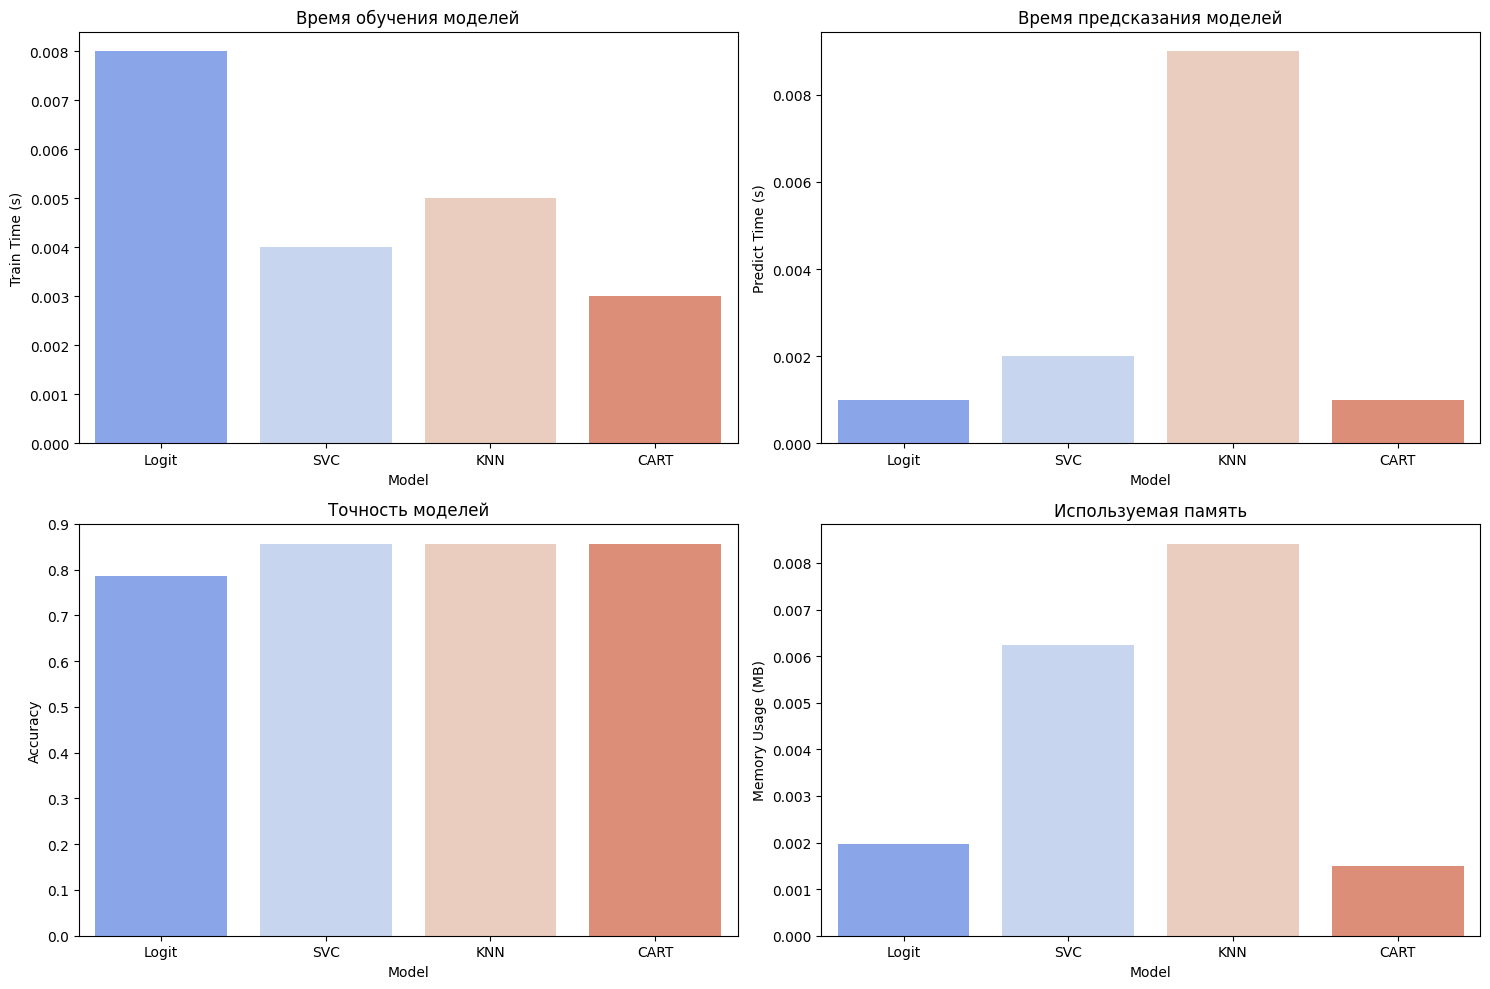

70


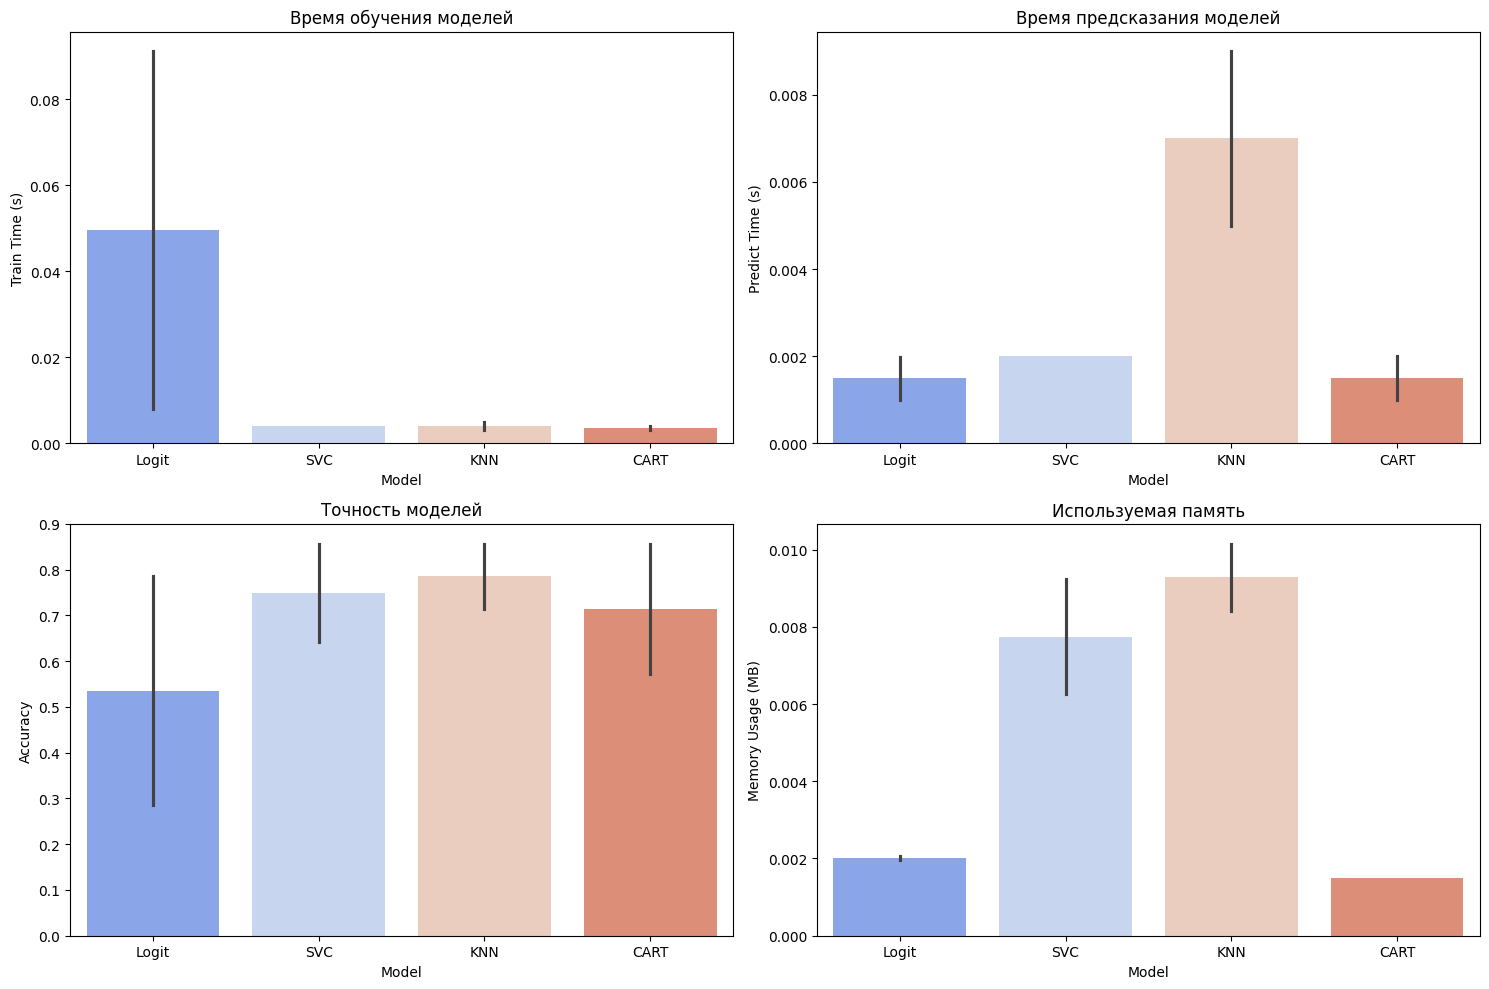

70


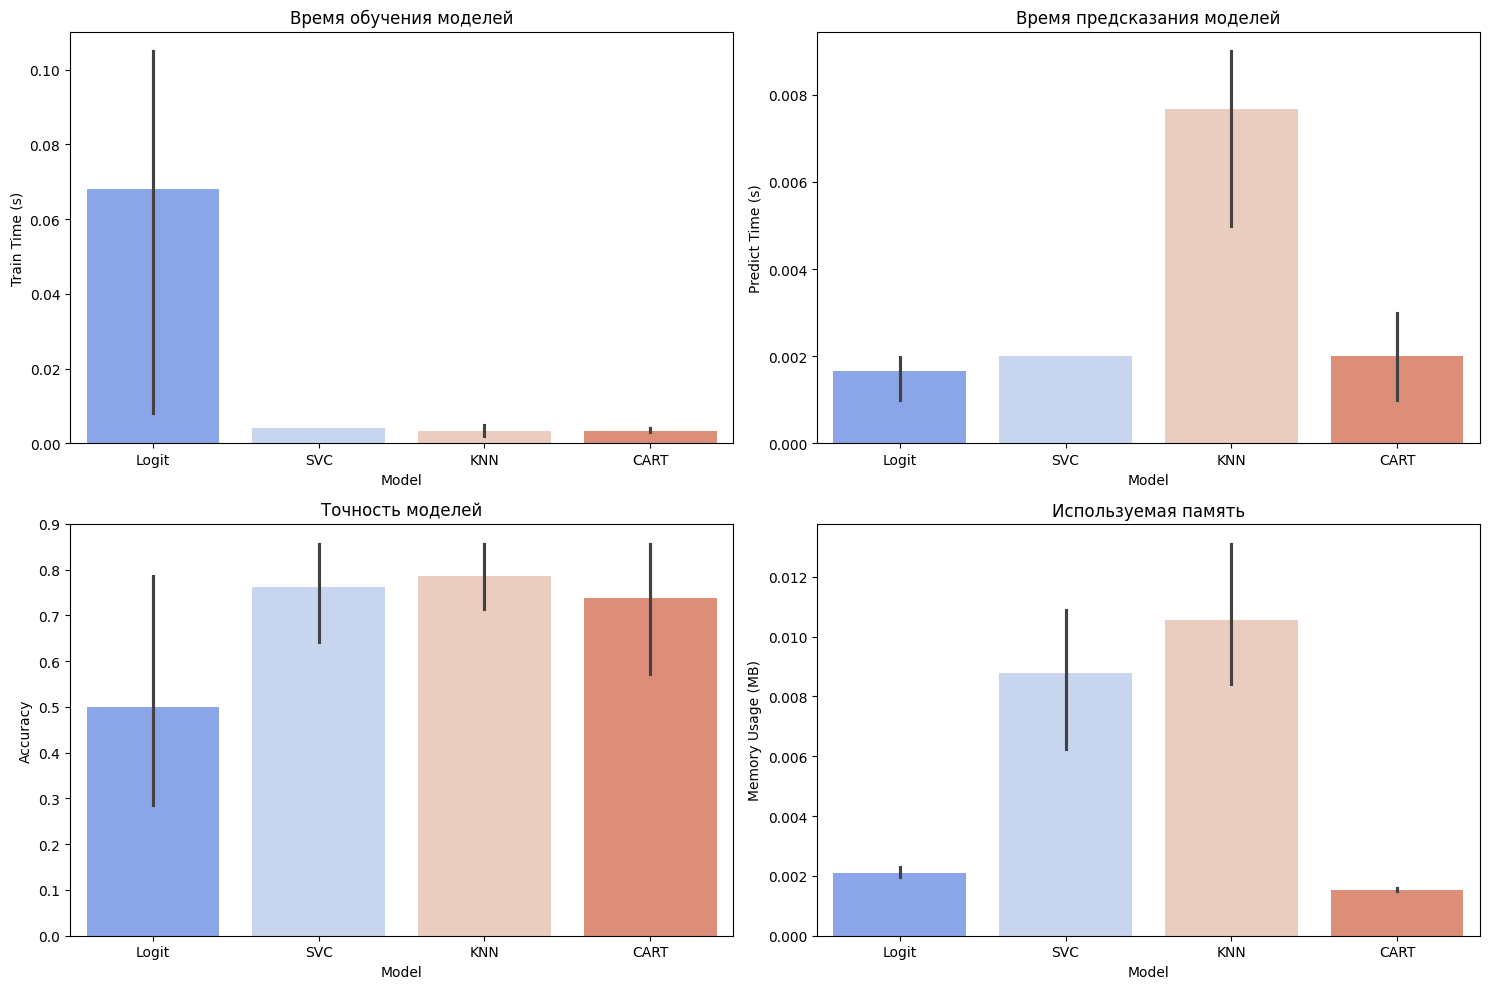

250


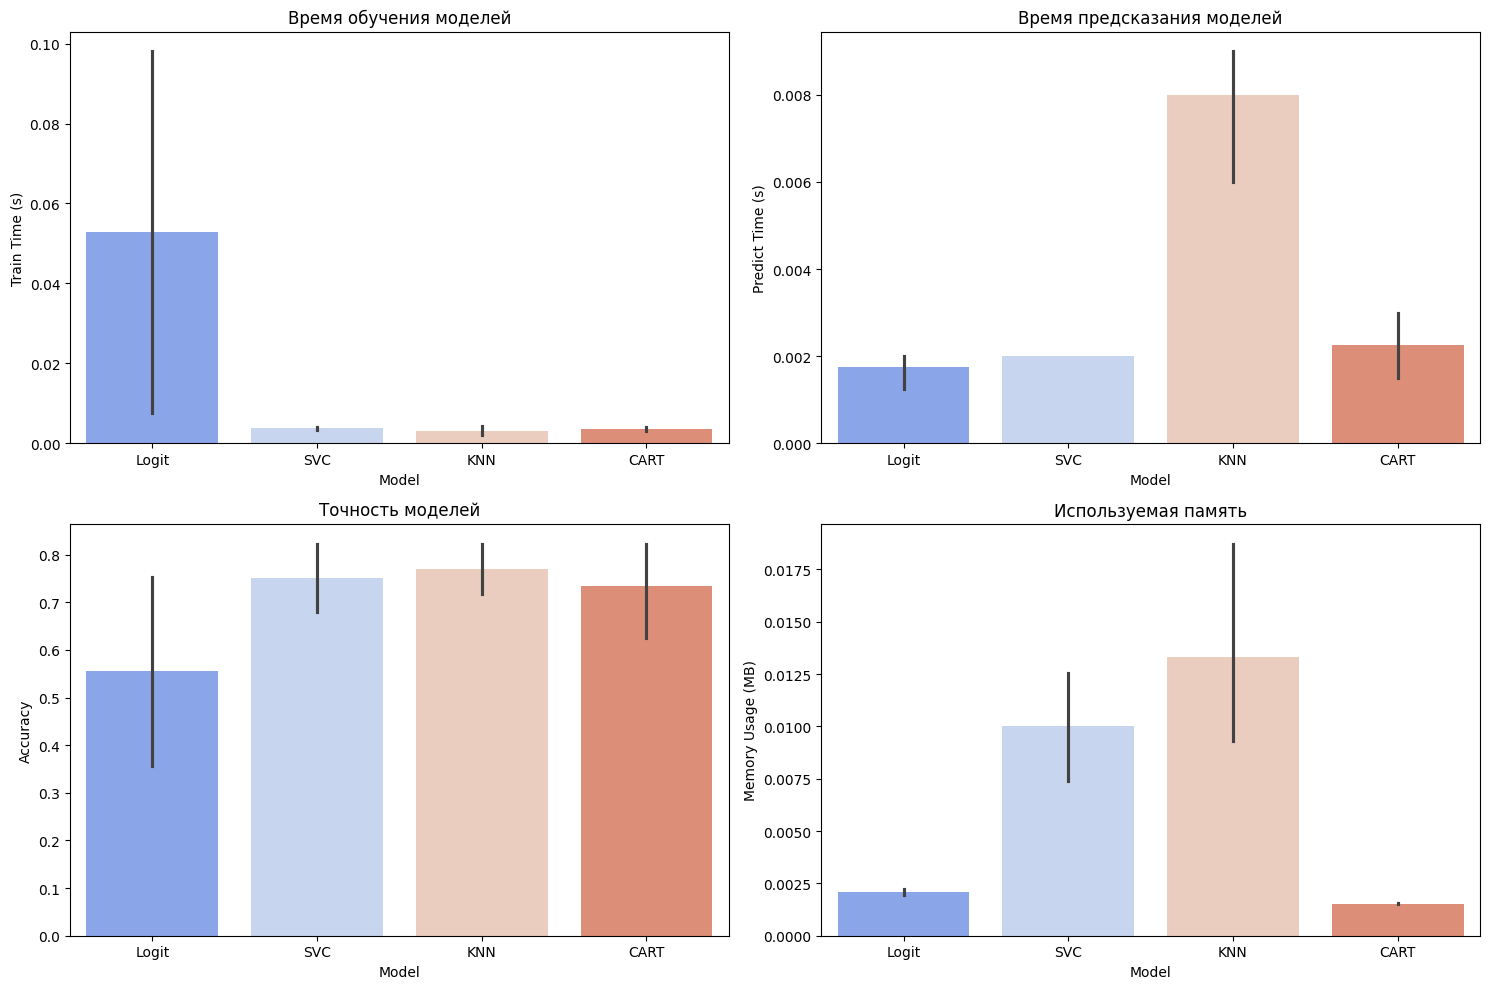

250


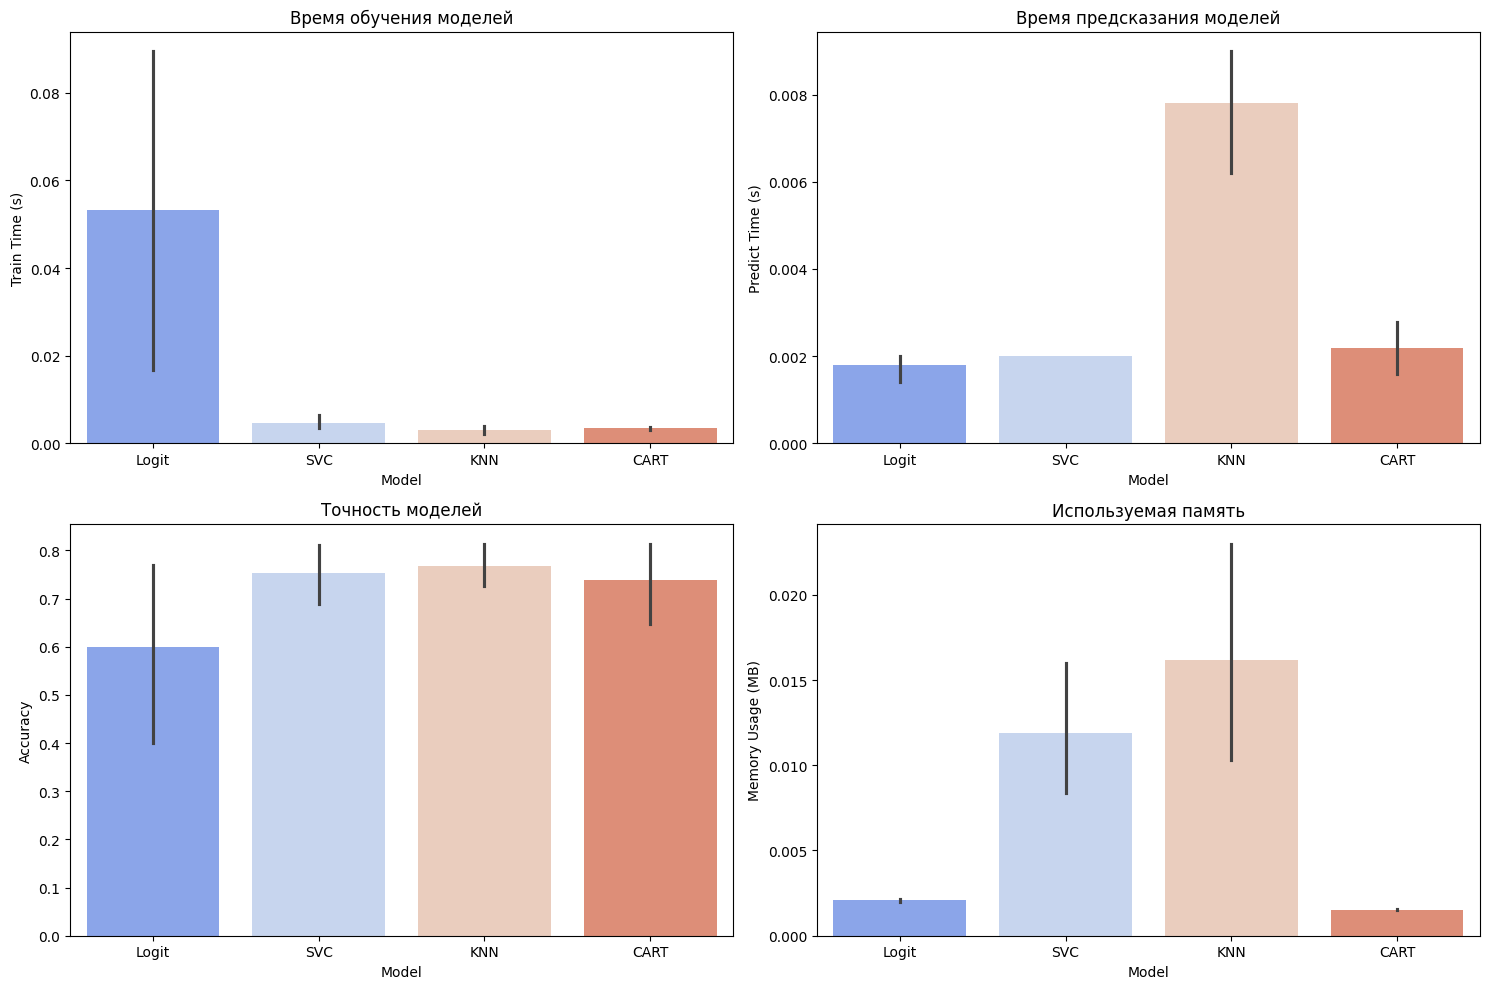

250


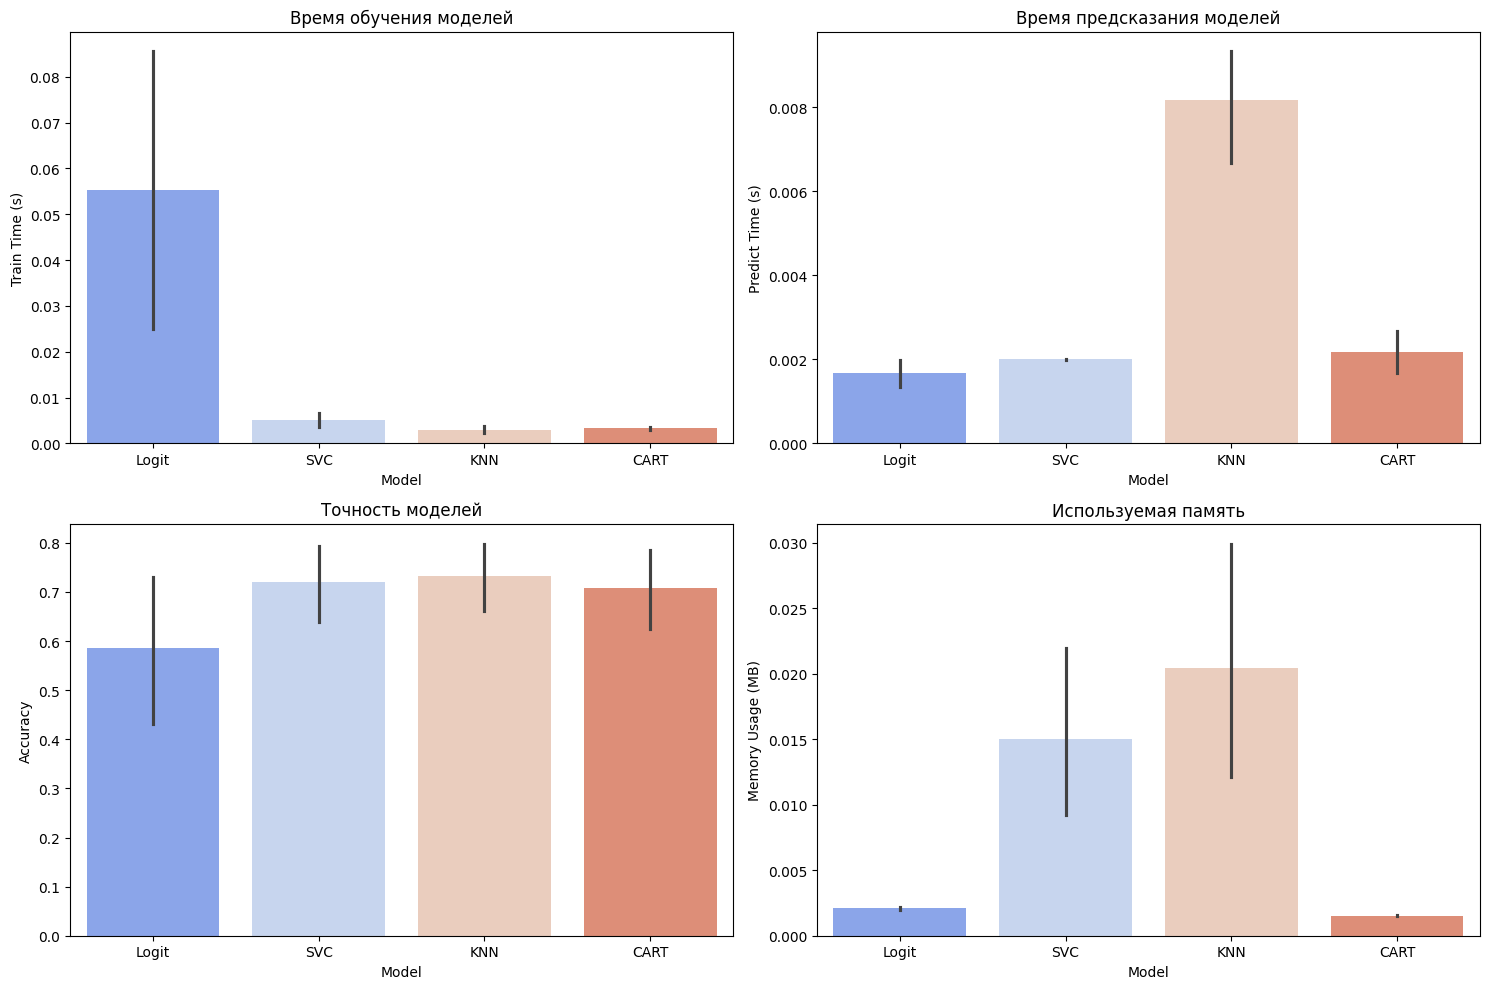

750


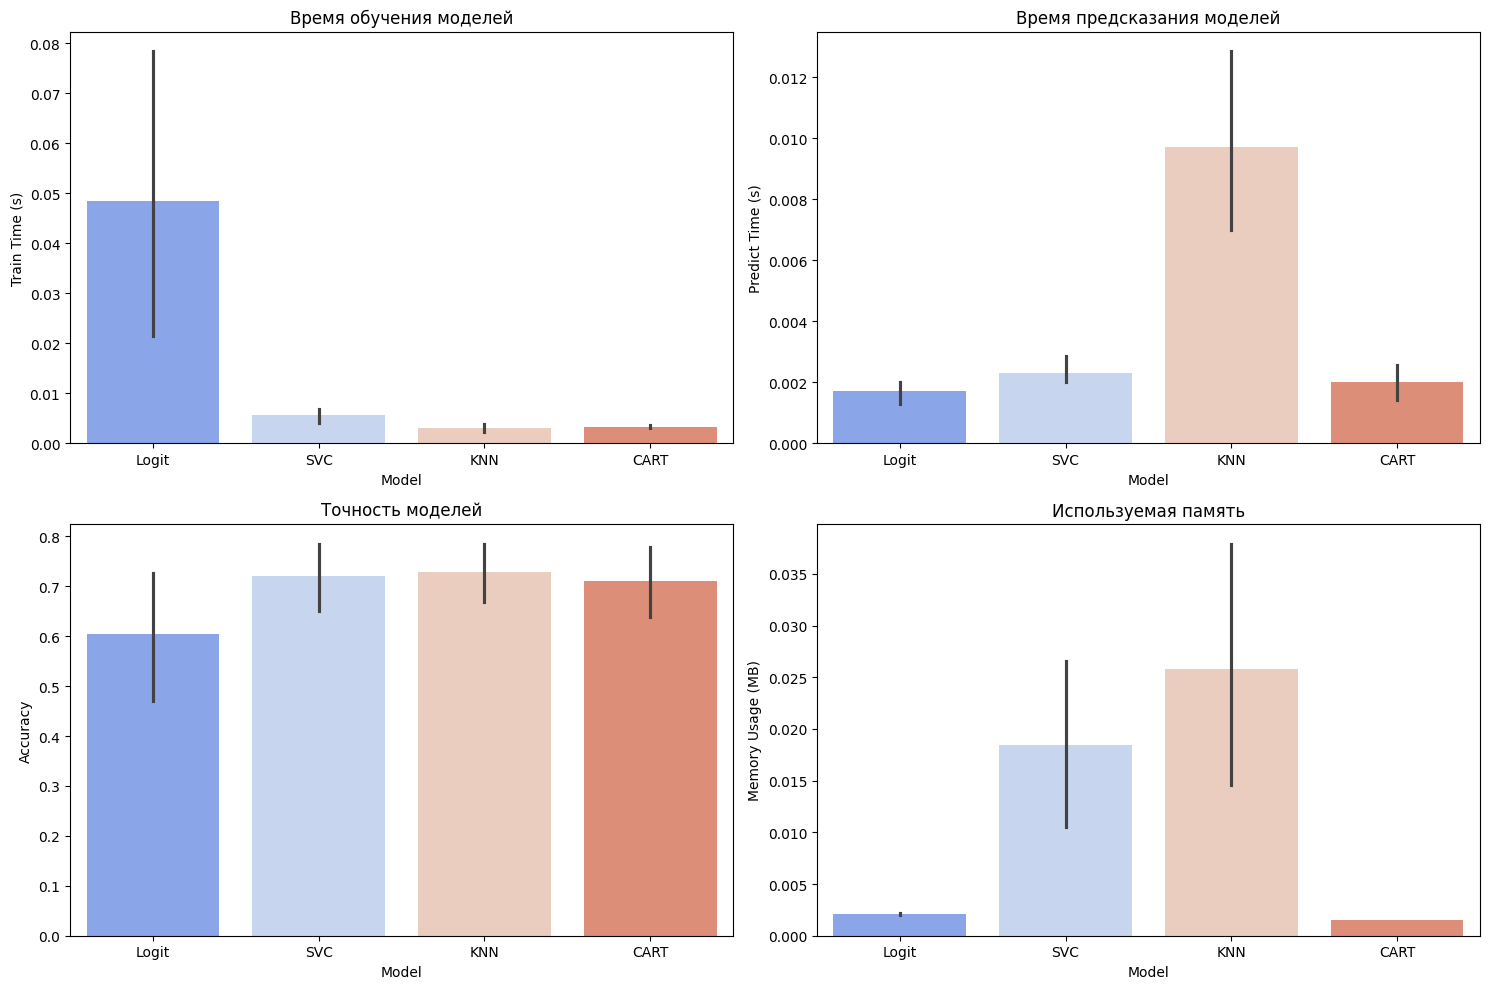

750


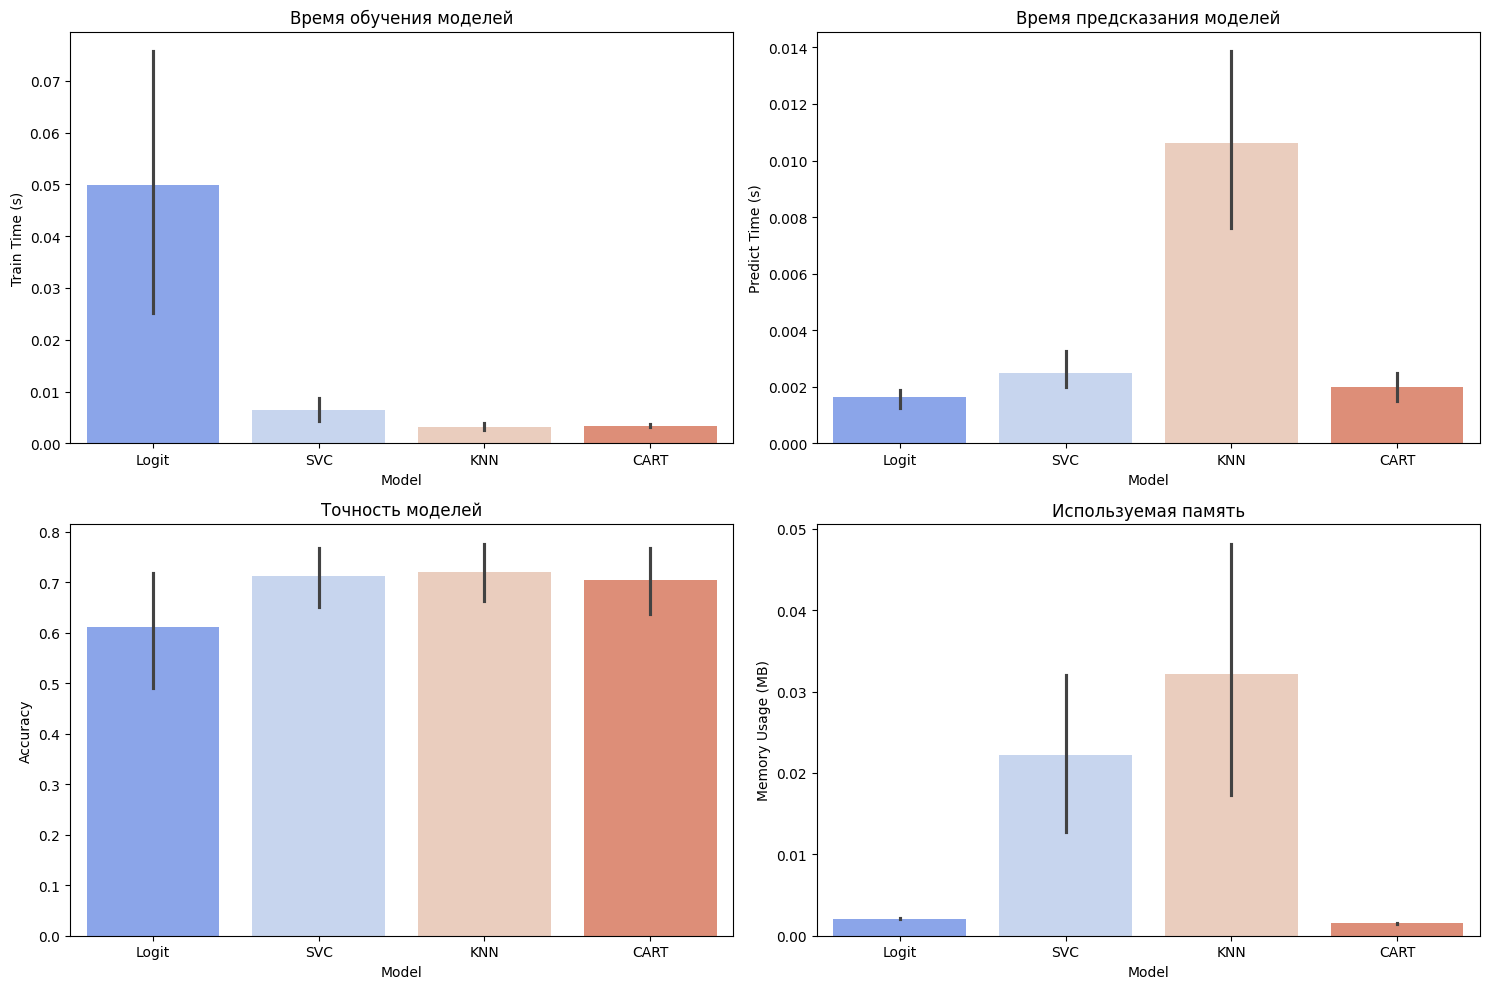

750


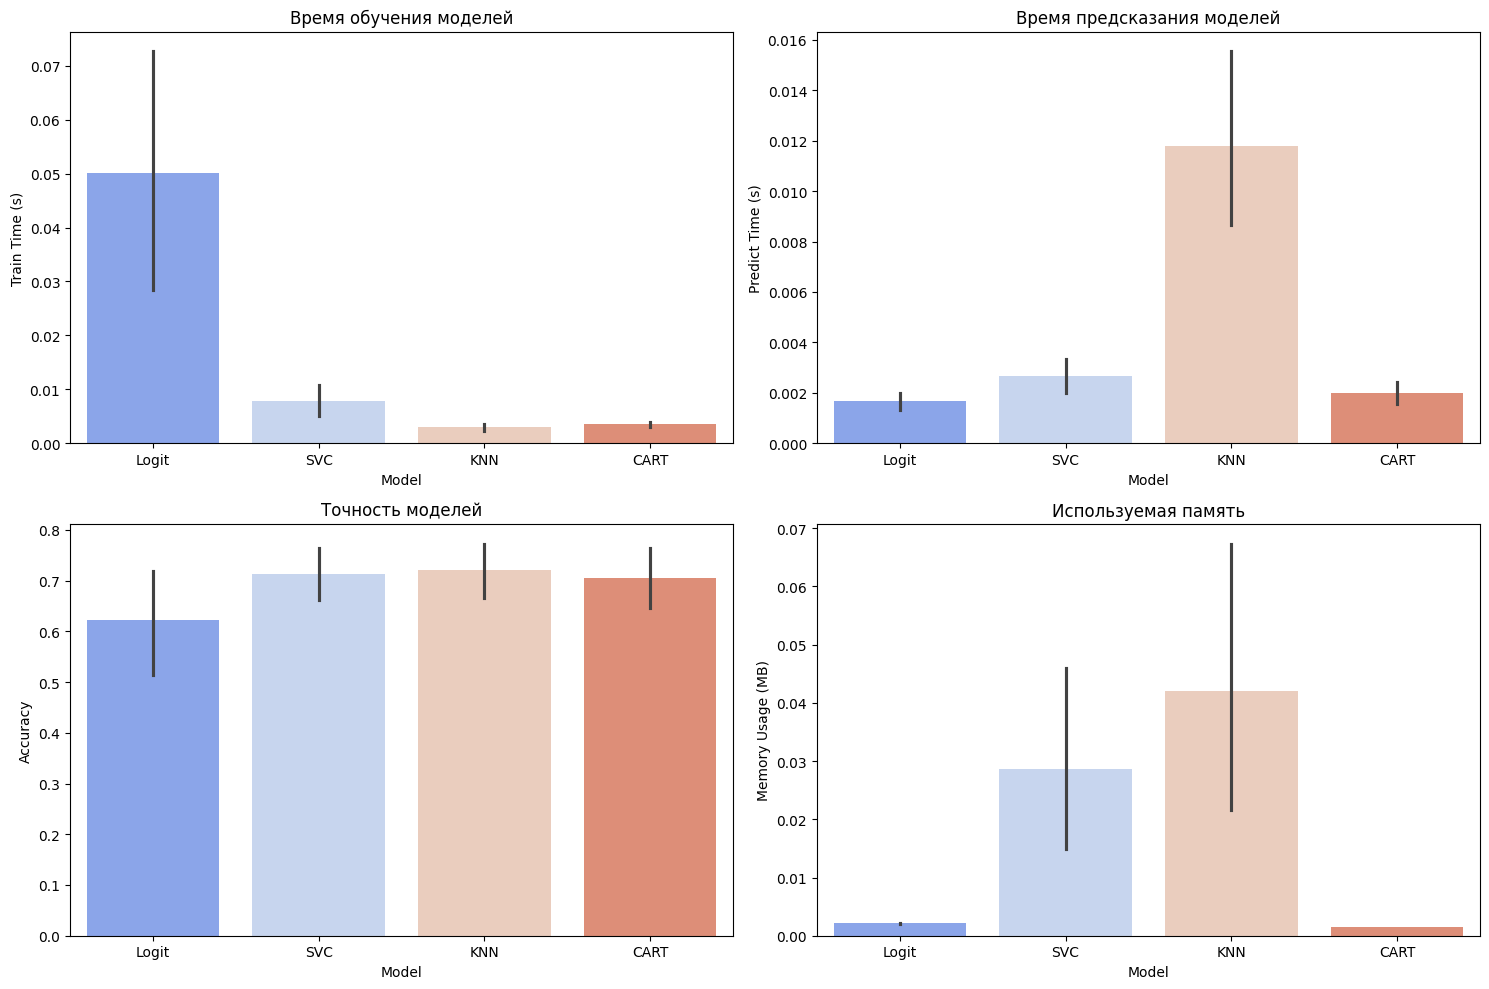

1500


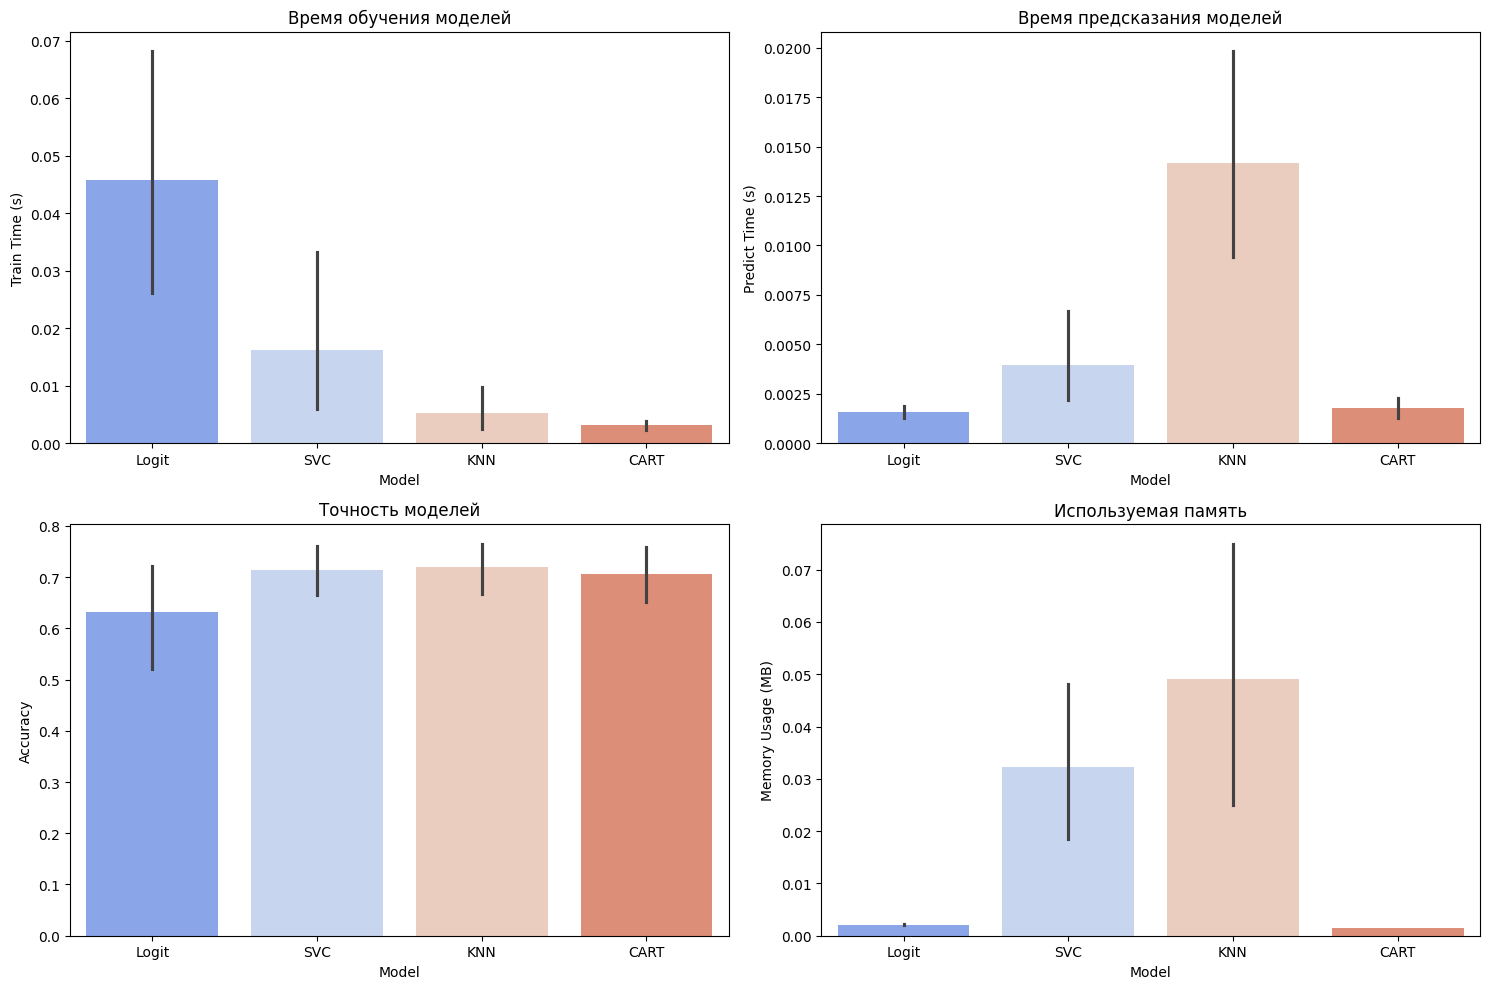

1500


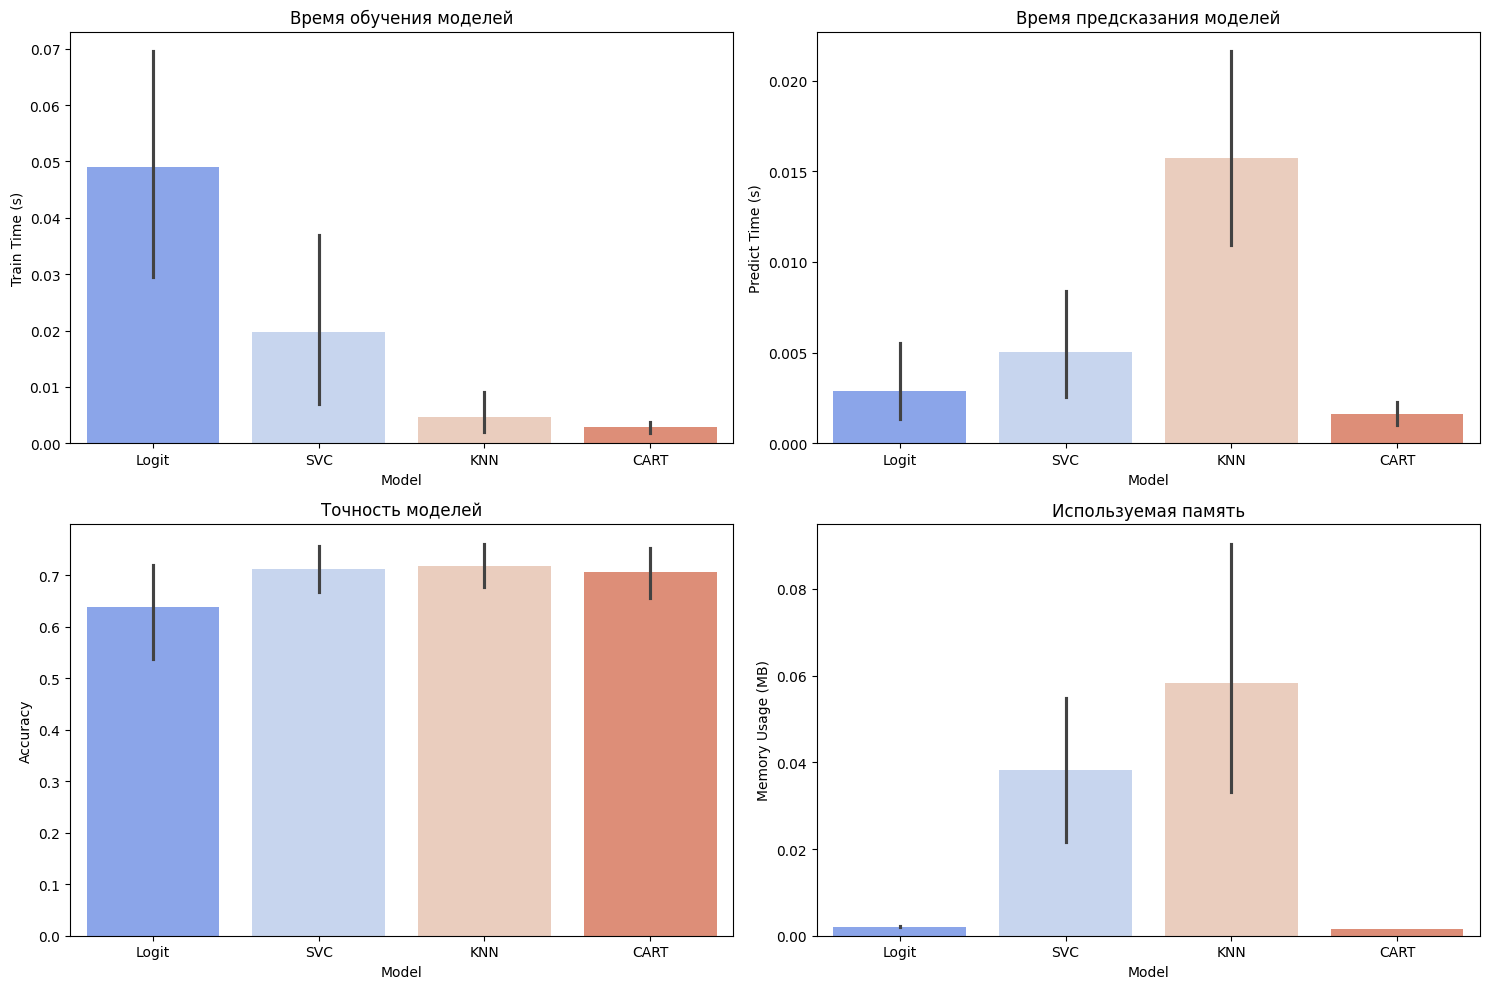

1500


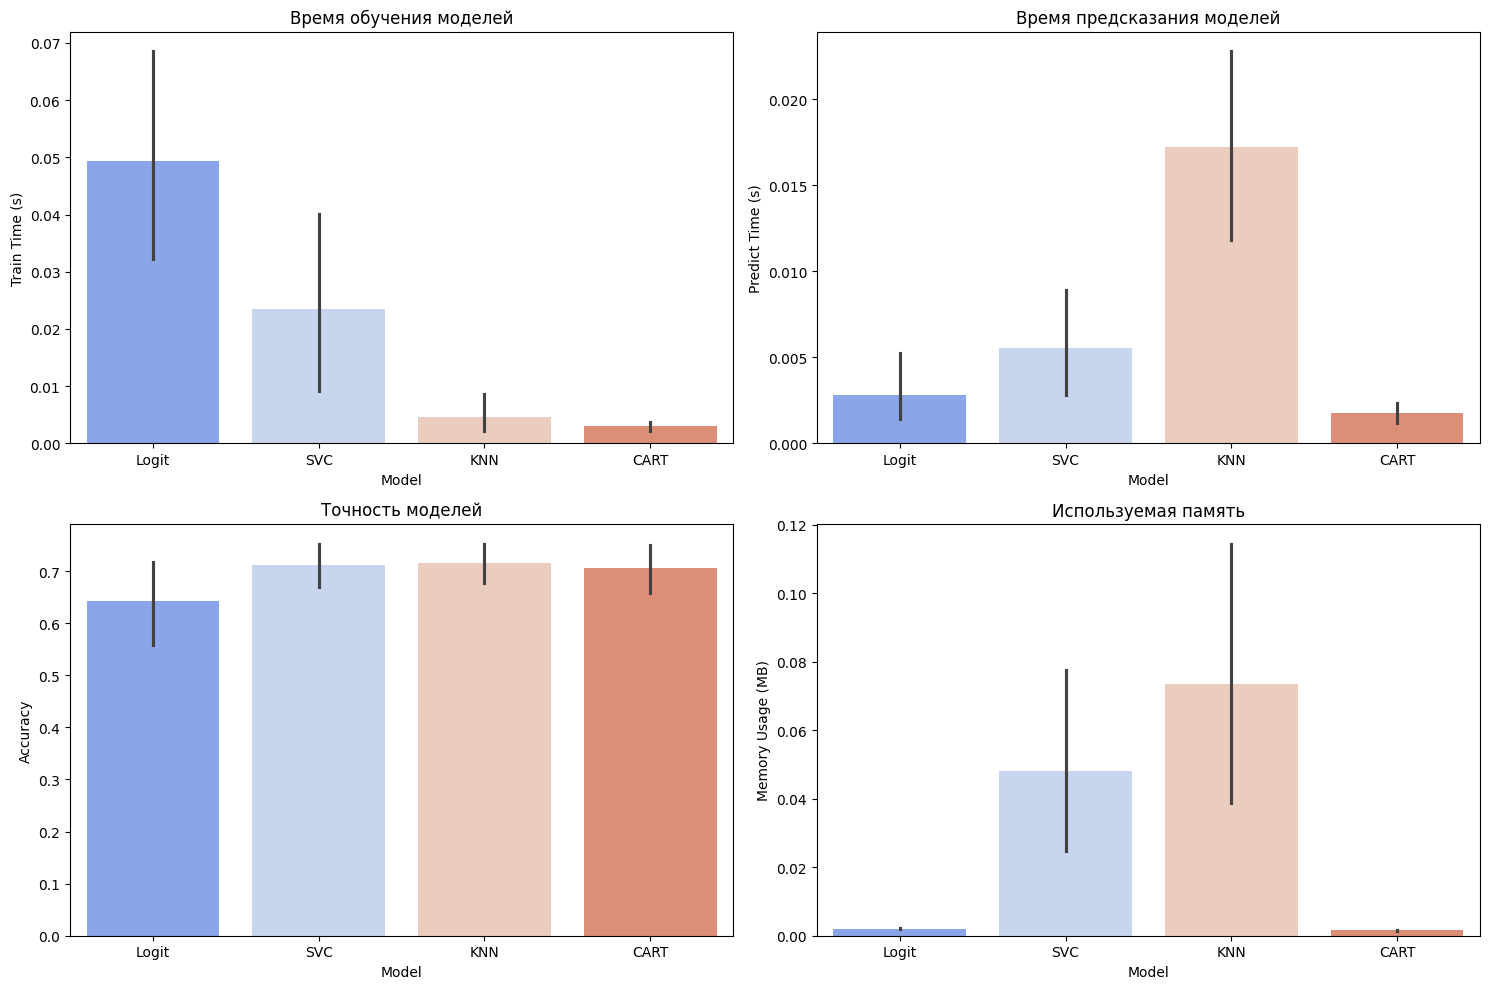

In [28]:
# Словарь для хранения результатов
results = {
    'Model': [],
    'Train Time (s)': [],
    'Predict Time (s)': [],
    'Memory Usage (MB)': [],
    'Accuracy': []
}

for data in dataframes:
    print(len(data))
    X = data.drop('collision', axis=1)
    y = data['collision']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    # Тестируем каждую модель
    for name, model_ in models.items():
        model = clone(model_)
        start_mem = asizeof(model)  # Память до обучения

        # Замеряем время обучения
        start_time = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_time

        # Замеряем время предсказания
        start_time = time.time()
        y_pred = model.predict(X_test)
        predict_time = time.time() - start_time

        # Оценка точности
        accuracy = accuracy_score(y_test, y_pred)

        # Оценка памяти (размер модели после обучения)
        model_size = (asizeof(model) - start_mem) / (1024 * 1024)

        # Записываем результаты
        results['Model'].append(name)
        results['Train Time (s)'].append(train_time)
        results['Predict Time (s)'].append(predict_time)
        results['Memory Usage (MB)'].append(model_size)
        results['Accuracy'].append(accuracy)

    df_results = pd.DataFrame(results)

    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    sns.barplot(x='Model', y='Train Time (s)', data=df_results, palette="coolwarm", hue="Model")
    plt.title("Время обучения моделей")

    plt.subplot(2, 2, 2)
    sns.barplot(x='Model', y='Predict Time (s)', data=df_results, palette="coolwarm", hue="Model")
    plt.title("Время предсказания моделей")

    plt.subplot(2, 2, 3)
    sns.barplot(x='Model', y='Accuracy', data=df_results, palette="coolwarm", hue="Model")
    plt.title("Точность моделей")

    plt.subplot(2, 2, 4)
    sizes = df_results['Memory Usage (MB)'] * 500  # Масштабируем
    sns.barplot(x='Model', y='Memory Usage (MB)', data=df_results, palette="coolwarm", hue="Model")
    plt.title("Используемая память")
    plt.tight_layout()
    plt.show()


Метод k-ближайших соседей (KNN) - отпадает в связи с длительным предсказанием и высоким объёмом памяти

In [21]:
joblib.dump(models['Logit'], "logit.joblib")
joblib.dump(models['SVC'], "svc.joblib")
joblib.dump(models['CART'], "cart.joblib")

['cart.joblib']

Оптимальный алгоритм - CART